Explained variance PC1: 0.17425902
Using neuron 9949 from VISp
a (slope): -0.036065682502161696
b (bias): 1.9346560387512295


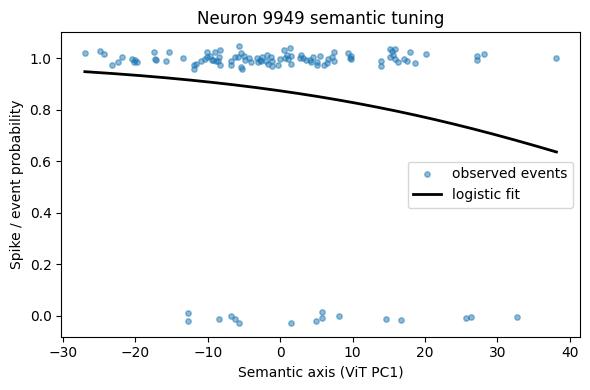

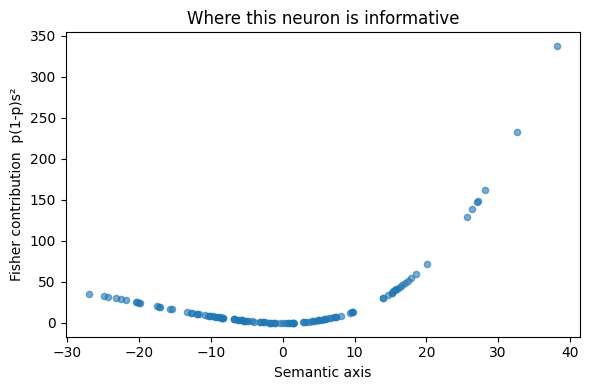

Total Fisher information: 23.172085209665855


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)                  # (neurons,)

# ============================================================
# SEMANTIC AXIS FROM ViT LOGITS
# ============================================================

# standardize logits
vit_z = StandardScaler().fit_transform(vit)

# PCA on logits
pca_vit = PCA(n_components=3)
vit_pca = pca_vit.fit_transform(vit_z)

semantic_axis = vit_pca[:, 0]   # PC1 = animate–inanimate axis (as you found)
print("Explained variance PC1:", pca_vit.explained_variance_ratio_[0])

# ============================================================
# PICK A SINGLE NEURON
# ============================================================

target_area = "VISp"
idx = np.where(areas == target_area)[0]
neuron_id = np.random.choice(idx)

y = R[:, neuron_id]      # shape (images,)
print("Using neuron", neuron_id, "from", target_area)
y_bin = (y > 0).astype(int)

## ============================================================
# LOGISTIC REGRESSION: neuron ~ semantic axis
# ============================================================

X = semantic_axis[:, None]

clf = LogisticRegression()
clf.fit(X, y_bin)

a = clf.coef_[0,0]
b = clf.intercept_[0]

print("a (slope):", a)
print("b (bias):", b)

# ============================================================
# PLOT SINGLE NEURON SEMANTIC TUNING
# ============================================================

s = np.linspace(semantic_axis.min(), semantic_axis.max(), 300)
p = 1 / (1 + np.exp(-(a*s + b)))

plt.figure(figsize=(6,4))
plt.scatter(semantic_axis, y_bin + 0.02*np.random.randn(len(y_bin)),
            s=15, alpha=0.5, label="observed events")

plt.plot(s, p, color='black', lw=2, label="logistic fit")
plt.xlabel("Semantic axis (ViT PC1)")
plt.ylabel("Spike / event probability")
plt.title(f"Neuron {neuron_id} semantic tuning")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# FISHER INFORMATION DENSITY ALONG SEMANTIC AXIS
# ============================================================

s_all = semantic_axis
p_all = clf.predict_proba(X)[:,1]

fisher_density = p_all * (1 - p_all) * (s_all**2)

plt.figure(figsize=(6,4))
plt.scatter(s_all, fisher_density, s=20, alpha=0.6)
plt.xlabel("Semantic axis")
plt.ylabel("Fisher contribution  p(1-p)s²")
plt.title("Where this neuron is informative")
plt.tight_layout()
plt.show()

print("Total Fisher information:", fisher_density.mean())
